## 1. Exploration

### 1.1 Problem context and set up

Given past history of order flow, how are we - as a market maker - able to tell the difference between noise and informed flow? For example, we may observe a sequence consisting of an overwhelmingly majority of buys, leading to an increasingly short inventory. If the event is truly noise, then we expect our inventory to revert back to its optimal amount based on our current strategy. But our short inventory is due to informed buying, then our inventory will be even more increasingly short. 

We can start with a toy problem. First, let us represent each buy and sell as the i.i.d. random variable $X_i$. $X_i$ can be interpreted as the signed trade of the $i$-th trade; it tells us the direction and quantity of the $i$-th trade.

$$ 
X_i = \begin{cases}
    +1 &i\text{-th trade } \text{ is a buy of 1 unit} \\
    -1 &i\text{-th trade } t \text{ is a sell of 1 unit}
\end{cases}
$$

where $i = 1, 2, ...$. Then the cumulative order flow is $S_n = \sum_{i=1}^n X_i$ and is interpreted as the net signed order flow after $n$ trades.

In [1]:
# libraries
import numpy as np
import matplotlib.pyplot as plt

def cum_ord_flow(n, p):
    """
    Inputs:
    n: number of trades
    p: probability of buy (independent of time)

    Outputs: 
    X = signed trade 
    S = cumulative order flow after n trades
    """

    # probability must be between 0 and 1
    if not 0 <= p <= 1:
        raise ValueError("p must be between 0 and 1.")

    # X_i
    X = np.random.choice([-1, 1], size=n-1, p=[1-p, p])

    # cumulative order flow
    S = np.zeros(n)

    for i in range(n-1):
        S[i+1] = S[i] + X[i]

    return X, S

### 1.2 Simple qualitative exploration using symmetric probabilities for fixed $n$

We first assume that $\mathbb{P}(\text{trade } i \text{ is a buy}) = p = 0.5$ and hence $\mathbb{P}(\text{trade } i \text{ is a sell}) = q = 1-p = 0.5$ and use $n = 10,000$ trades/steps. 

Under these probabilities, our cumulative order flow $S_n$ is a symmetric random walk. 

We first explore by simulating $N = 10$ different sample paths to qualitatively understand the variability of cumulative order flow given the same market structure.

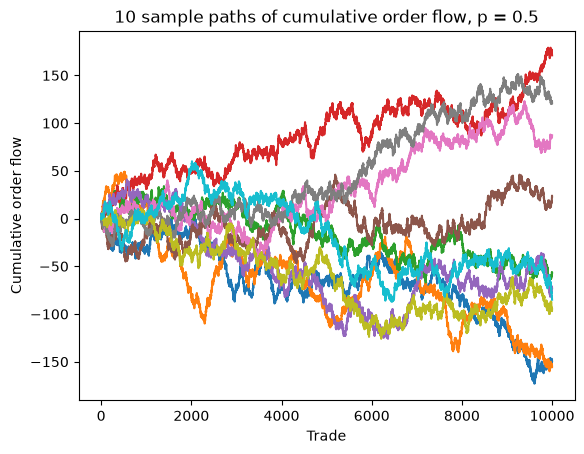

In [2]:
# cumulative order flow simulation under equal probabilities and n = 10000 steps
n = 10**4
p = 0.5

# plotting N = 10 different sample paths
N = 10
for i in range(N):
    # cumulative sample paths
    X, S = cum_ord_flow(n = n, p = p)
    plt.plot(np.arange(n), S)

# plotting cumulative order flow
plt.title(f"10 sample paths of cumulative order flow, p = {p}")
plt.xlabel("Trade")
plt.ylabel("Cumulative order flow")
plt.show()

We can run the above code many times and observe that the 10 sample paths generate quite variable paths. For some runs, the majority of the paths have negative cumulative order flow whereas for other runs, the signs cumulative order flow quite evenly spread throughout. If cumulative order flow is truly noise with symmetric probabilities and $n = 10,000$, the sample paths can vary quite a lot. As a result, it will be difficult to tell the difference between noise and informed buying as large cumulative imbalances can arise from noise as seen in the simulation.

Now we use larger $N = 1,000$ to explore the empirical distribution of the terminal value of our cumulative order flow under the same, fixed $p = 0.5$ and $n = 10,000$. We'll also plot the theoretical distribution which is derived below.

Recall the i.i.d random variable $X_i$ is

$$ 
X_i = \begin{cases}
    +1 &\mathbb{P}(i\text{-th trade } \text{ is a buy of 1 unit}) = p \\
    -1 &\mathbb{P}(i\text{-th trade } \text{ is a sell of 1 unit}) = 1 - p
\end{cases}
$$

Then the first moment is, 

$$
\mathbb{E}(X_i) = 1 \cdot p + (-1) \cdot (1 - p) = 2p - 1 
$$. 

We also have the second moment 

$$
\mathbb{E}(X_i^2) = (1)^2 \cdot p + (-1)^2 \cdot (1-p) = 1
$$.

Therefore the variance is 

\begin{align*}
    \mathbb{V}\text{ar}(X_i) 
        &= \mathbb{E}(X_i^2) - \mathbb{E}(X_i)^2 \\
        &= 1 - (2p - 1)^2 \\ 
        &= -4p^2 + 4p \\
        &= 4p(1 - p)
\end{align*}

Also $S_n = \sum_{i=1}^n X_i$. By linearity and identicalness, 

$$\mathbb{E}(S_n^{(j)}) = n(2p-1) \text{ and } \mathbb{V}\text{ar}(S_n^{(j)}) = 4np(1-p)$$

for all $j = 1, 2, ..., N$.

For large $n$, by the Central Limit Theorem, $S_n^{(j)} \sim N(n(2p-1), 4np(1-p)$ approximately. 

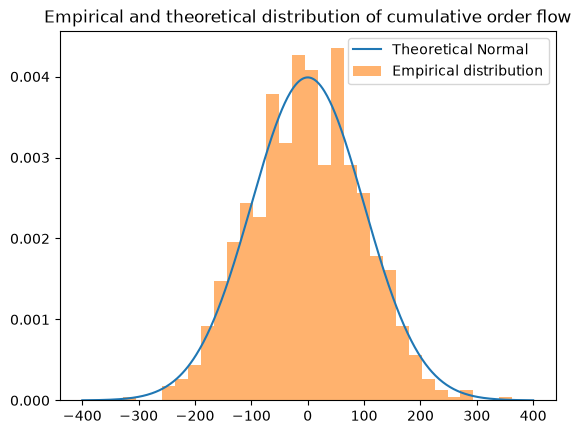

In [ ]:
# library
from scipy.stats import norm

# empirical distribution of terminal values
N = 1000
term_values = np.zeros(N)

for i in range(N):
    # cumulative sample paths
    term_values[i] = cum_ord_flow(n = n, p = p)[1][-1]

# theoretical normal statistics
mu = n * (2*p - 1)
sigma = np.sqrt(4*n*p*(1-p))

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
y = norm.pdf(x, loc=mu, scale=sigma)

# plotting 
# normal distribution
plt.plot(x, y, label="Theoretical Normal")
plt.legend()

# empirical distribution
plt.hist(term_values, bins=30, density=True, alpha = 0.6, label = "Empirical distribution")
plt.legend()
plt.title(label = "Empirical and theoretical distribution of cumulative order flow")
plt.show()

There is quite a lot of variability between the individual sample paths as seen in the previous plot. Despite this, when we look at the terminal values across many paths, they are approximately normally distributed around 0. This shows that a path can have periods of quite strong buying or selling even when there is no actual bias in the underlying order flow. So if we observe what looks like strong buying, this alone isn't enough to say that informed buying is occurring — it could just be noise from a symmetric order flow process.

### 1.3 Varying probabilities $p$ with fixed $n$

We now start to explore what happens to our sample paths when we vary the probability $p$ using some fixed $n$. 

The values of $p$ are chosen to represent increasingly strong buy-side biases (i.e. $p \geq 0.5$). The same values will be used across each $n$ so that the effect of changing the number of observed trades can be compared directly. 

In [28]:
# function that plots the cumulative order flows using different N, n, and p
def plot_cum_order_flow(N, n, p_values):
    """
    Inputs:
    N: number of sample paths
    n: number of trades
    p_values: probabilities of a buy
    """

    # cumulative order flow simulation under different probabilities

    fig, axes = plt.subplots(
        2, 2,
        figsize=(12, 8),
        sharex=True,
        sharey=True
    )

    # for different p
    for ax, p in zip(axes.flat, p_values):

        # plotting N different sample paths for different values of p
        for i in range(N):

            # cumulative sample paths
            X, S = cum_ord_flow(n=n, p=p)

            ax.plot(np.arange(n), S)

        # plotting cumulative order flow
        ax.set_title(f"p = {p}")
        ax.set_xlabel("Trade")
        ax.set_ylabel("Cumulative order flow")

    fig.suptitle(
        f"{N} sample paths of cumulative order flow using {n} trades"
    )

    plt.tight_layout()
    plt.show()

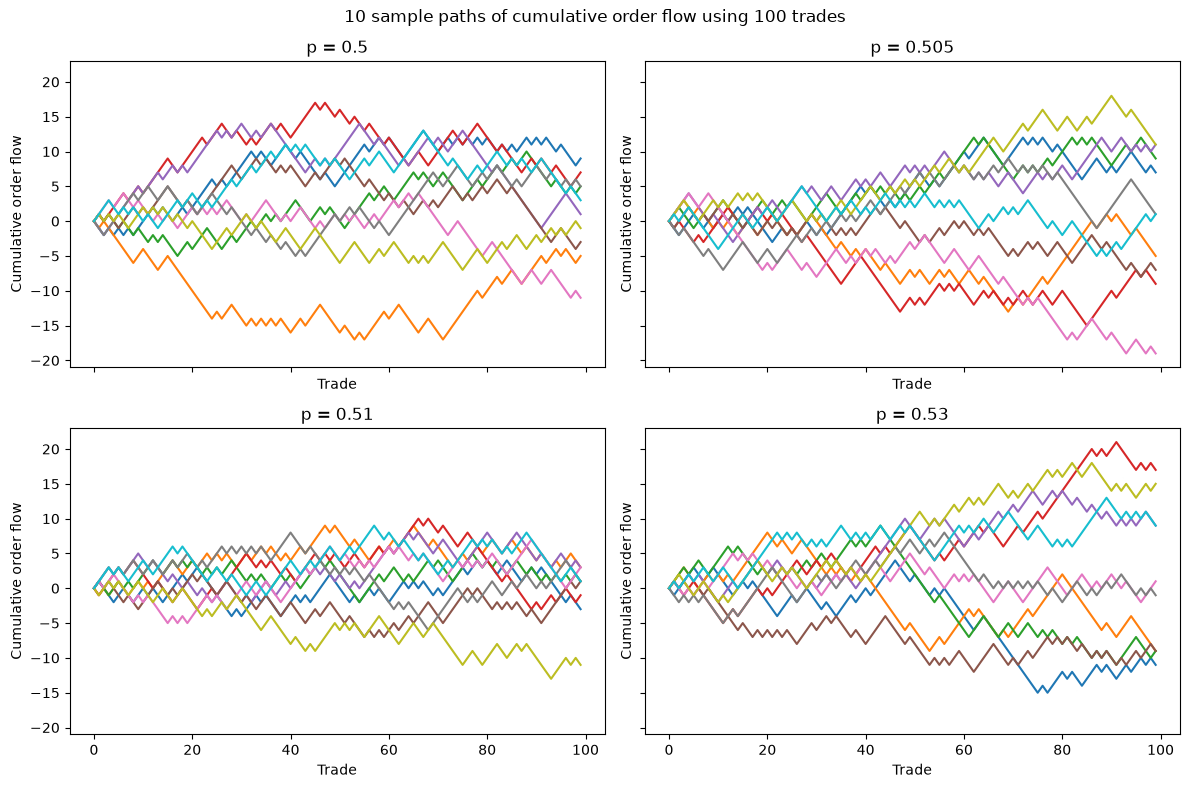

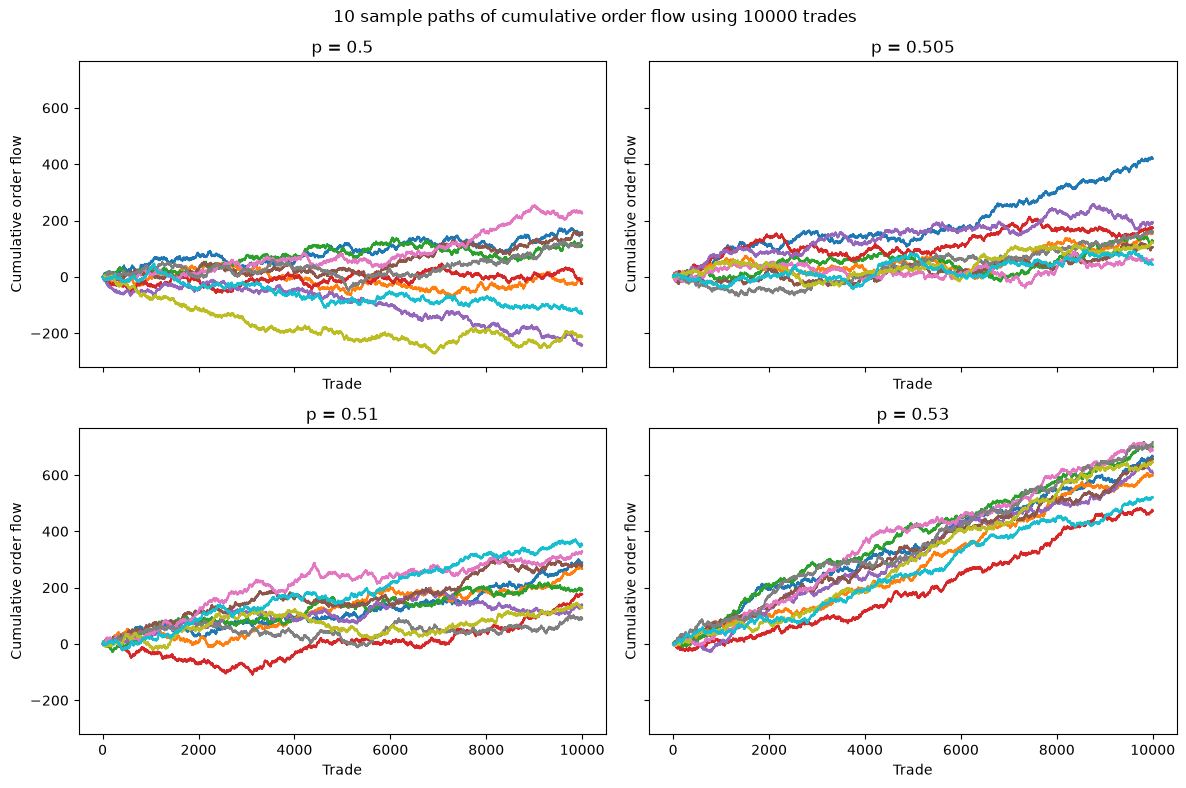

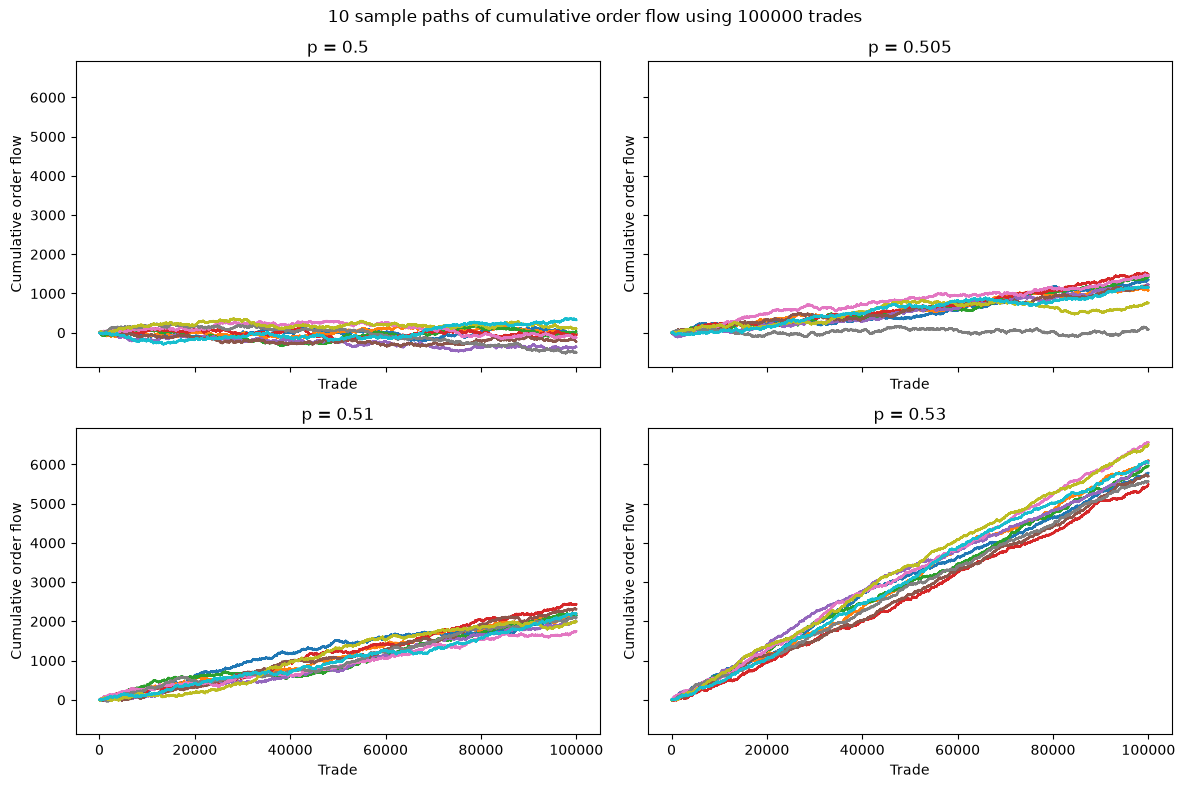

In [31]:
# same p-values across n = 100, 1000, 10000 trades
p_values = np.array([0.5, 0.505, 0.51, 0.53])

plot_cum_order_flow(N=10, n=10**2, p_values=p_values)
plot_cum_order_flow(N=10, n=10**4, p_values=p_values)
plot_cum_order_flow(N=10, n=10**5, p_values=p_values)